## Download data

In [63]:
from __future__ import annotations

import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import missingno as msno

import numpy as np


from dataclasses import dataclass

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [46]:
MARKET_METADATA = {
    "^N225": {
        "name": "Nikkei 225",
        "country": "Japan",
        "open_utc": "00:00",
        "close_utc": "06:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^HSI": {
        "name": "Hang Seng",
        "country": "Hong Kong",
        "open_utc": "01:30",
        "close_utc": "08:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "000001.SS": {
        "name": "Shanghai Composite",
        "country": "China",
        "open_utc": "01:30",
        "close_utc": "07:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "399001.SZ": {
        "name": "Shenzhen Component",
        "country": "China",
        "open_utc": "01:30",
        "close_utc": "07:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^KS11": {
        "name": "KOSPI",
        "country": "South Korea",
        "open_utc": "00:00",
        "close_utc": "06:30",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^TWII": {
        "name": "Taiwan Weighted",
        "country": "Taiwan",
        "open_utc": "01:00",
        "close_utc": "05:30",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^AXJO": {
        "name": "ASX 200",
        "country": "Australia",
        "open_utc": "00:00",
        "close_utc": "06:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^BSESN": {
        "name": "SENSEX",
        "country": "India",
        "open_utc": "03:45",
        "close_utc": "10:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },

    "^GDAXI": {
        "name": "DAX",
        "country": "Germany",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^FCHI": {
        "name": "CAC 40",
        "country": "France",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^FTSE": {
        "name": "FTSE 100",
        "country": "UK",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^IBEX": {
        "name": "IBEX 35",
        "country": "Spain",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "FTSEMIB.MI": {
        "name": "FTSE MIB",
        "country": "Italy",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^BVSP": {
        "name": "Bovespa",
        "country": "Brazil",
        "open_utc": "13:00",
        "close_utc": "20:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },

    "^GSPC": {
        "name": "S&P 500",
        "country": "USA",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^NDX": {
        "name": "NASDAQ 100",
        "country": "USA",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^DJI": {
        "name": "Dow Jones",
        "country": "USA",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^RUT": {
        "name": "Russell 2000",
        "country": "USA",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^GSPTSE": {
        "name": "TSX Composite",
        "country": "Canada",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^MXX": {
        "name": "IPC Mexico",
        "country": "Mexico",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
}

In [47]:
OHLCV_COLUMNS = ["open", "high", "low", "close", "volume"]


def download_yfinance_daily_raw(
    tickers: list[str],
    period: str = "max",
    auto_adjust: bool = False,
) -> pd.DataFrame:
    """Descarga histórico diario bruto desde Yahoo Finance."""
    return yf.download(
        tickers=tickers,
        period=period,
        interval="1d",
        auto_adjust=auto_adjust,
        progress=True,
        threads=True,
        group_by="ticker",
    )


def build_ohlcv_dict_from_raw(
    raw: pd.DataFrame,
    tickers: list[str],
    ohlcv_columns: list[str] | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Convierte la descarga bruta de yfinance en un diccionario:
        {
            ticker: DataFrame[open, high, low, close, volume]
        }
    """
    selected_columns = ohlcv_columns or OHLCV_COLUMNS
    data_by_ticker: dict[str, pd.DataFrame] = {}

    for ticker in tickers:
        if isinstance(raw.columns, pd.MultiIndex):
            if ticker not in raw.columns.get_level_values(0):
                print(f"No encontrado en descarga: {ticker}")
                continue

            df_ticker = raw[ticker].copy()
        else:
            df_ticker = raw.copy()

        df_ticker.columns = (
            df_ticker.columns
            .str.lower()
            .str.replace(" ", "_", regex=False)
        )

        df_ticker = df_ticker.drop(
            columns=["adj_close"],
            errors="ignore",
        )

        available_columns = [
            col for col in selected_columns
            if col in df_ticker.columns
        ]

        if not available_columns:
            print(f"Sin columnas OHLCV válidas: {ticker}")
            continue

        df_ticker = df_ticker[available_columns].copy()
        df_ticker.index.name = "date"
        df_ticker = df_ticker.sort_index()

        data_by_ticker[ticker] = df_ticker

    return data_by_ticker

In [48]:
tickers = list(MARKET_METADATA.keys())

raw_data = download_yfinance_daily_raw(
    tickers=tickers,
    period="max",
    auto_adjust=False,
)

data_by_ticker = build_ohlcv_dict_from_raw(
    raw=raw_data,
    tickers=tickers,
)

data_by_ticker["^GSPC"].head()

[*********************100%***********************]  20 of 20 completed


Price,open,high,low,close,volume
date,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,0.0
1928-01-03,17.760000,17.760000,17.760000,17.760000,0.0
1928-01-04,17.719999,17.719999,17.719999,17.719999,0.0
1928-01-05,17.549999,17.549999,17.549999,17.549999,0.0
1928-01-06,17.660000,17.660000,17.660000,17.660000,0.0


In [49]:
data_by_ticker["^GSPC"].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 25245 entries, 1927-12-30 to 2026-06-05
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    24724 non-null  float64
 1   high    24724 non-null  float64
 2   low     24724 non-null  float64
 3   close   24724 non-null  float64
 4   volume  24724 non-null  float64
dtypes: float64(5)
memory usage: 1.2 MB


In [50]:
for ticker, df_ticker in data_by_ticker.items():
    print(
        ticker,
        df_ticker.shape,
        df_ticker.index.min(),
        df_ticker.index.max(),
    )

^N225 (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^HSI (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
000001.SS (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
399001.SZ (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^KS11 (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^TWII (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^AXJO (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^BSESN (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^GDAXI (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^FCHI (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^FTSE (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^IBEX (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
FTSEMIB.MI (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^BVSP (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^GSPC (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^NDX (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^DJI (25245, 5) 1927-12-30 00:00:00 2026-06-05 00:00:00
^RUT (25245, 5) 192

## Data preparation

### 1. Nulls

In [51]:
# Juntar temporalmente todos los dataframes

df_concat = pd.concat(
    data_by_ticker,
    axis=1,
)

# Aplanar multiíndice de columnas
df_concat.columns = [
    f"{ticker}_{feature}"
    for ticker, feature in df_concat.columns
]

df_concat = df_concat.sort_index()

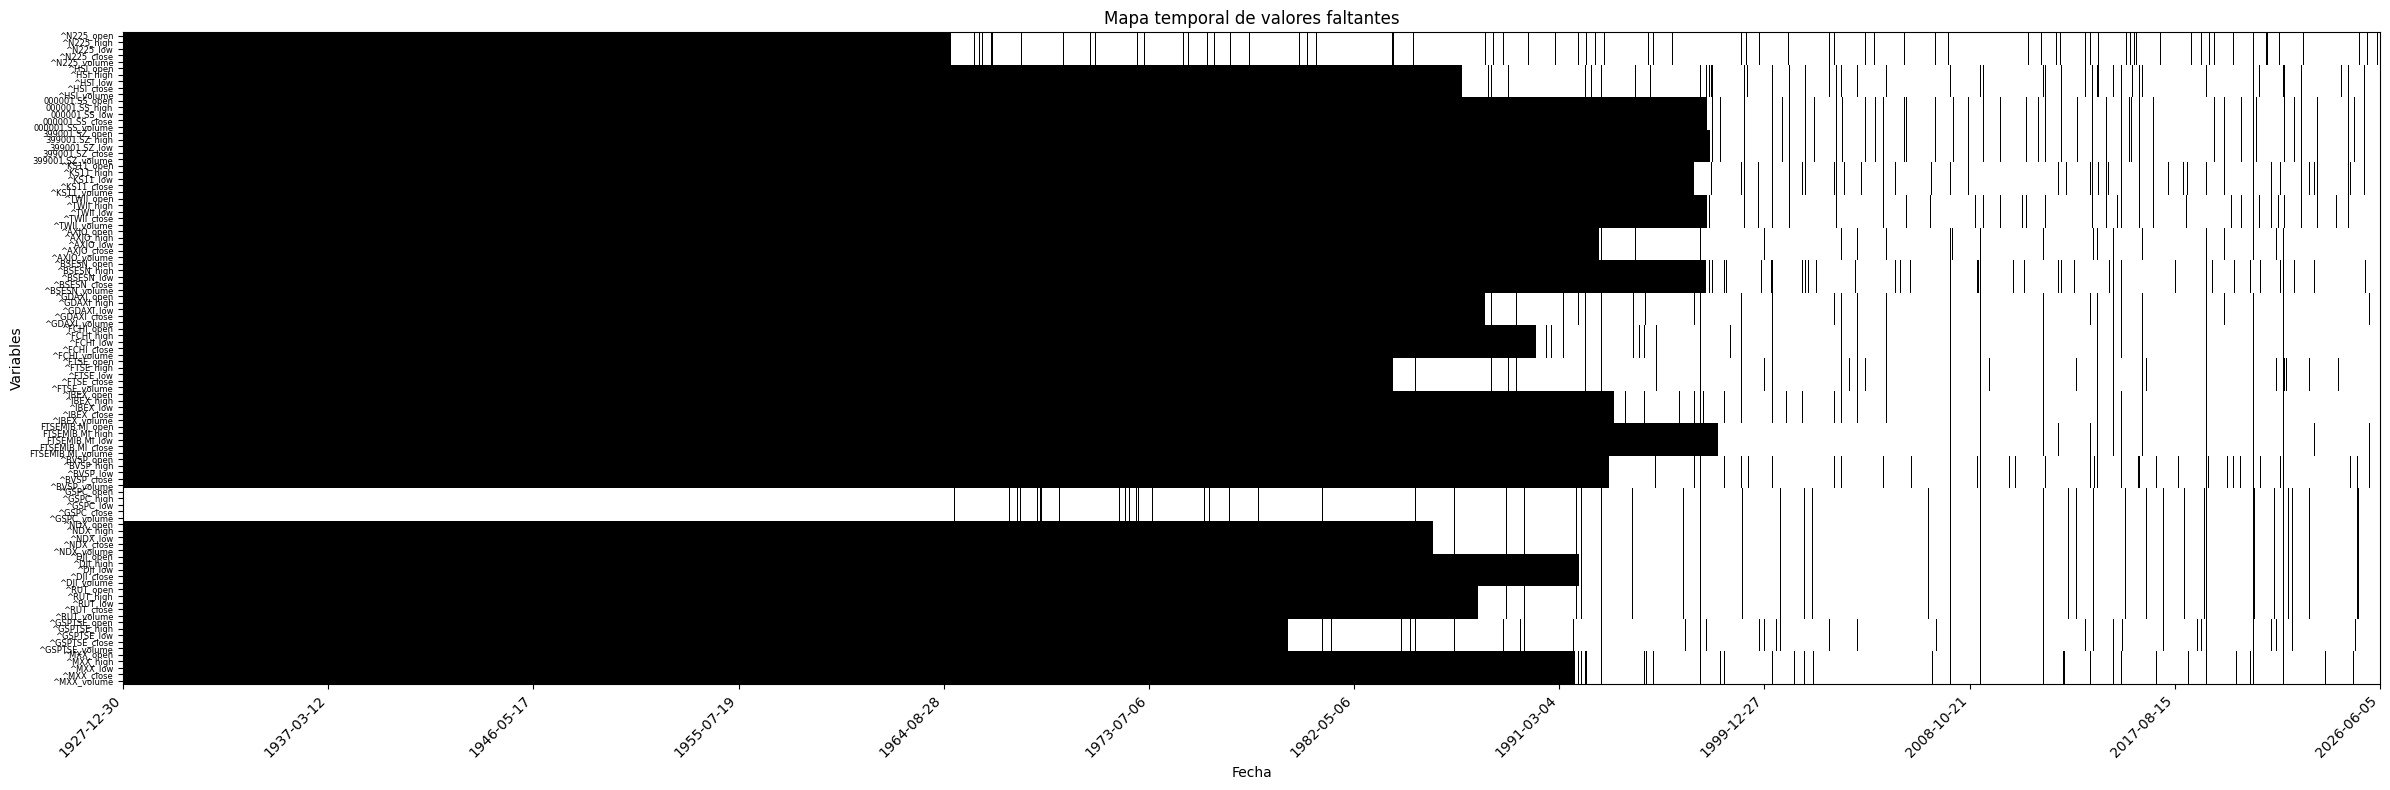

In [52]:

# Plot de nulos

fig, ax = plt.subplots(figsize=(24, 8))

im = ax.imshow(
    df_concat.isna().T,
    aspect="auto",
    interpolation="none",
    cmap="binary",
)

n_ticks = 12

tick_positions = np.linspace(
    0,
    len(df_concat.index) - 1,
    n_ticks,
    dtype=int,
)

tick_labels = (
    pd.to_datetime(
        df_concat.index[tick_positions]
    )
    .strftime("%Y-%m-%d")
)

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(df_concat.columns))
)

ax.set_yticklabels(
    df_concat.columns,
    fontsize=6,
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Variables")
ax.set_title("Mapa temporal de valores faltantes")

plt.tight_layout()
plt.show()

In [53]:
coverage = (
    1 - df_concat.isna().mean(axis=1)
)

start_date = coverage[coverage >= 0.90].index.min()

print(f"Fecha de inicio con al menos 90% de cobertura: {start_date.date()}")

Fecha de inicio con al menos 90% de cobertura: 1997-07-03


In [54]:
summary = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "first_valid_date": df.dropna(how="all").index.min(),
            "last_valid_date": df.dropna(how="all").index.max(),
            "n_rows": len(df),
        }
        for ticker, df in data_by_ticker.items()
    ]
)

summary.sort_values("first_valid_date")

,ticker,first_valid_date,last_valid_date,n_rows
14,^GSPC,1927-12-30,2026-06-05,25245
0,^N225,1965-01-05,2026-06-05,25245
18,^GSPTSE,1979-06-29,2026-06-05,25245
10,^FTSE,1984-01-03,2026-06-05,25245
15,^NDX,1985-10-01,2026-06-05,25245
1,^HSI,1986-12-31,2026-06-05,25245
17,^RUT,1987-09-10,2026-06-05,25245
8,^GDAXI,1987-12-30,2026-06-05,25245
9,^FCHI,1990-03-01,2026-06-05,25245
19,^MXX,1991-11-08,2026-06-05,25245


Para tu proyecto de predicción del SPX, la pregunta práctica es:

¿Desde qué fecha puedo asumir que los mercados mundiales están suficientemente integrados electrónicamente como para que las señales internacionales tengan sentido?

Yo usaría una de estas fechas:

* 1990 → inicio de la globalización financiera moderna.
* 1995 → Internet y expansión masiva de negociación electrónica.
* 2000 → prácticamente todas las grandes bolsas relevantes ya son electrónicas.

Si tuviera que elegir una única fecha para un modelo de ML sobre índices globales, elegiría:

2000-01-01

porque:

Ya existen Nikkei, Hang Seng, DAX, EuroStoxx, KOSPI, etc.
La infraestructura electrónica es dominante.
La correlación entre mercados globales es mucho más parecida a la actual.
Evitas entrenar con regímenes de mercado muy distintos (años 30, Bretton Woods, mercados cerrados, etc.).

In [59]:
START_DATE = "2000-01-01"

def preprocess_data_by_ticker(
    data_by_ticker: dict[str, pd.DataFrame],
    start_date: str = "2000-01-01",
) -> dict[str, pd.DataFrame]:
    """
    Preprocesa cada índice:

    1. Corta desde start_date.
    2. Reindexa a todos los días laborables (freq='B').
    3. Guarda flags indicando qué valores estaban ausentes.
    4. Aplica forward fill.
    5. Añade día de la semana codificado en seno/coseno.

    Output por ticker:

        open
        high
        low
        close
        volume

        day_of_week_sin
        day_of_week_cos

        open_was_filled
        high_was_filled
        low_was_filled
        close_was_filled
        volume_was_filled
    """

    start_date = pd.Timestamp(start_date)

    max_date = max(
        df.index.max()
        for df in data_by_ticker.values()
    )

    business_days = pd.date_range(
        start=start_date,
        end=max_date,
        freq="B",
    )

    processed_data: dict[str, pd.DataFrame] = {}

    for ticker, df in data_by_ticker.items():

        # Cortar histórico
        df = df.loc[start_date:].copy()

        # Asegurar orden temporal
        df = df.sort_index()

        # Insertar días laborables faltantes
        df = df.reindex(business_days)

        df.index.name = "date"

        # Guardar dónde faltaban datos ANTES del ffill
        missing_mask = df.isna()

        fill_flags = (
            missing_mask
            .astype(np.int8)
            .add_suffix("_was_filled")
        )

        # Forward fill
        df = df.ffill()

        # Día de la semana
        # Lunes=0 ... Viernes=4
        day_of_week = df.index.dayofweek

        # Desplazamiento angular para evitar
        # senos/cosenos exactamente iguales a 0
        angle = (
            2 * np.pi * day_of_week / 7
            + np.pi / 13
        )

        df["day_of_week_sin"] = np.sin(angle)
        df["day_of_week_cos"] = np.cos(angle)

        # Concatenar todo
        df = pd.concat(
            [
                df,
                fill_flags,
            ],
            axis=1,
        )

        processed_data[ticker] = df

    return processed_data

In [76]:
data_by_ticker_processed = preprocess_data_by_ticker(
    data_by_ticker=data_by_ticker,
    start_date="1998-01-01",
)

In [77]:
data_by_ticker_processed["^GSPC"].head()

Price,open,high,low,close,volume,day_of_week_sin,day_of_week_cos,open_was_filled,high_was_filled,low_was_filled,close_was_filled,volume_was_filled
date,,,,,,,,,,,,
1998-01-01,NaN,NaN,NaN,NaN,NaN,0.205660,-0.978624,1,1,1,1,1
1998-01-02,970.429993,975.039978,965.729980,975.039978,366730000.0,-0.636892,-0.770953,0,0,0,0,0
1998-01-05,975.039978,982.630005,969.000000,977.070007,628070000.0,0.239316,0.970942,0,0,0,0,0
1998-01-06,977.070007,977.070007,962.679993,966.580017,618360000.0,0.908324,0.418268,0,0,0,0,0
1998-01-07,966.580017,966.580017,952.669983,964.000000,667390000.0,0.893346,-0.449370,0,0,0,0,0


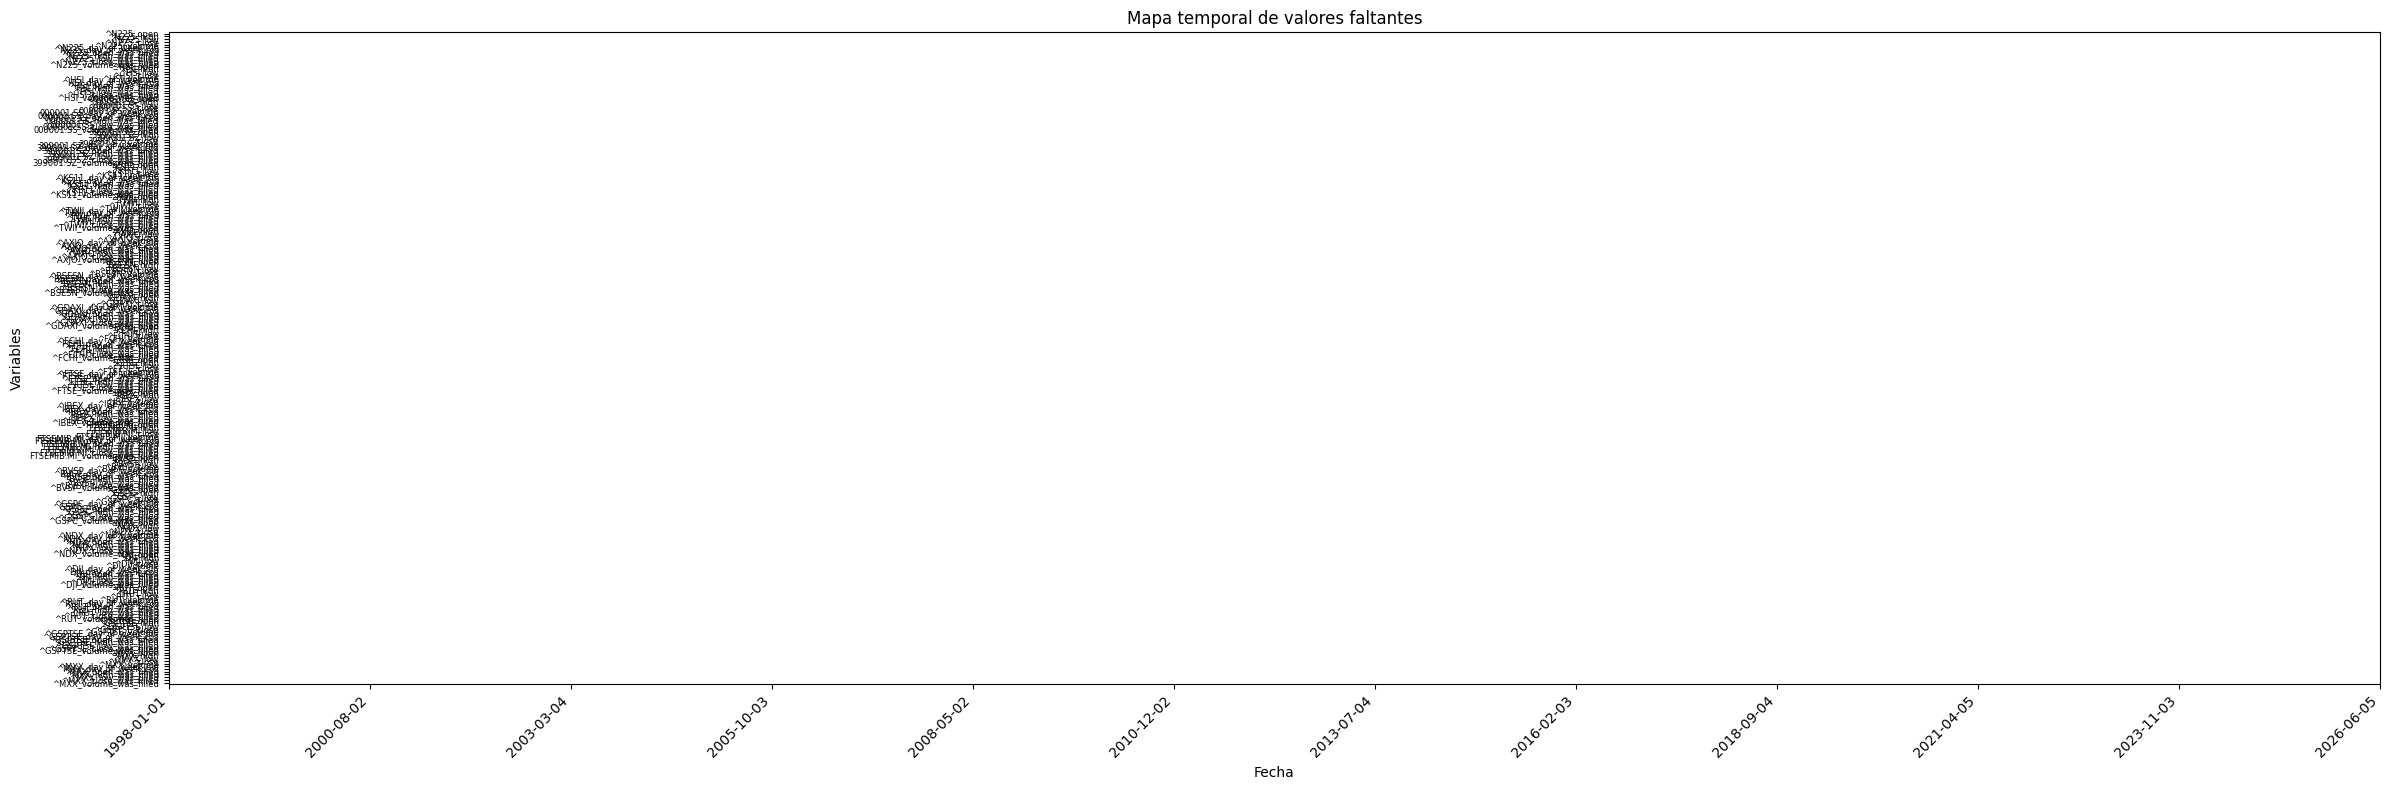

In [78]:
# Juntar temporalmente todos los dataframes

df_concat_processed = pd.concat(
    data_by_ticker_processed,
    axis=1,
)

# Aplanar multiíndice de columnas
df_concat_processed.columns = [
    f"{ticker}_{feature}"
    for ticker, feature in df_concat_processed.columns
]

df_concat_processed = df_concat_processed.sort_index()


# Plot de nulos

fig, ax = plt.subplots(figsize=(24, 8))

im = ax.imshow(
    df_concat_processed.isna().T,
    aspect="auto",
    interpolation="none",
    cmap="binary",
)

n_ticks = 12

tick_positions = np.linspace(
    0,
    len(df_concat_processed.index) - 1,
    n_ticks,
    dtype=int,
)

tick_labels = (
    pd.to_datetime(
        df_concat_processed.index[tick_positions]
    )
    .strftime("%Y-%m-%d")
)

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(df_concat_processed.columns))
)

ax.set_yticklabels(
    df_concat_processed.columns,
    fontsize=6,
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Variables")
ax.set_title("Mapa temporal de valores faltantes")

plt.tight_layout()
plt.show()

### 2. Features in returns

In [79]:

PRICE_COLUMNS = ["open", "high", "low", "close"]
VOLUME_COLUMN = "volume"


def get_fracdiff_weights(
    d: float,
    threshold: float = 1e-4,
    max_size: int = 1_000,
) -> np.ndarray:
    """Calcula pesos de diferenciación fraccional."""
    weights = [1.0]

    for k in range(1, max_size):
        weight = -weights[-1] * (d - k + 1) / k

        if abs(weight) < threshold:
            break

        weights.append(weight)

    return np.array(weights[::-1], dtype=np.float64)


def fracdiff_series(
    series: pd.Series,
    d: float = 0.4,
    threshold: float = 1e-4,
) -> pd.Series:
    """Aplica diferenciación fraccional a una serie."""
    weights = get_fracdiff_weights(
        d=d,
        threshold=threshold,
    )

    width = len(weights)
    values = series.to_numpy(dtype=np.float64)

    output = np.full(
        shape=len(values),
        fill_value=np.nan,
        dtype=np.float64,
    )

    for i in range(width - 1, len(values)):
        window = values[i - width + 1:i + 1]

        if np.isnan(window).any():
            continue

        output[i] = np.dot(weights, window)

    return pd.Series(
        output,
        index=series.index,
        name=series.name,
    )


def build_return_features(
    data_by_ticker: dict[str, pd.DataFrame],
    d: float = 0.4,
    fracdiff_threshold: float = 1e-4,
) -> dict[str, pd.DataFrame]:
    """
    Construye retornos logarítmicos y retornos con diferenciación fraccional.

    Input por ticker:
        open, high, low, close, volume,
        day_of_week_sin, day_of_week_cos,
        *_was_filled

    Output por ticker:
        open_logret
        open_logret_fd
        high_logret
        high_logret_fd
        low_logret
        low_logret_fd
        close_logret
        close_logret_fd
        volume_log
        day_of_week_sin
        day_of_week_cos
        *_was_filled
    """
    features_by_ticker: dict[str, pd.DataFrame] = {}

    for ticker, df in data_by_ticker.items():
        features = pd.DataFrame(index=df.index)

        for col in PRICE_COLUMNS:
            logret_col = f"{col}_logret"
            fd_col = f"{logret_col}_fd"

            features[logret_col] = np.log(df[col]).diff()

            features[fd_col] = fracdiff_series(
                series=features[logret_col],
                d=d,
                threshold=fracdiff_threshold,
            )

        features["volume_log"] = np.log1p(df[VOLUME_COLUMN])

        passthrough_cols = [
            col
            for col in df.columns
            if (
                col.endswith("_was_filled")
                or col in {"day_of_week_sin", "day_of_week_cos"}
            )
        ]

        features = pd.concat(
            [features, df[passthrough_cols]],
            axis=1,
        )
        # Eliminar filas donde aún quedan NaNs
        features = features.dropna()

        # Seguridad
        features = features.sort_index()

        features_by_ticker[ticker] = features

    return features_by_ticker

In [80]:
features_by_ticker = build_return_features(
    data_by_ticker=data_by_ticker_processed,
    d=0.4,
    fracdiff_threshold=1e-4,
)

In [81]:
features_by_ticker["^GSPC"].head()

,open_logret,open_logret_fd,high_logret,high_logret_fd,low_logret,low_logret_fd,close_logret,close_logret_fd,volume_log,day_of_week_sin,day_of_week_cos,open_was_filled,high_was_filled,low_was_filled,close_was_filled,volume_was_filled
date,,,,,,,,,,,,,,,,
1999-02-02,-0.005202,-0.012106,-0.008024,-0.011279,-0.018858,-0.025854,-0.008686,-0.009345,20.555439,0.908324,0.418268,0,0,0,0,0
1999-02-03,-0.008686,-0.009372,0.002000,0.003519,0.006161,0.010972,0.007956,0.010351,20.591447,0.893346,-0.449370,0,0,0,0,0
1999-02-04,0.007956,0.010328,-0.002990,-0.004003,-0.005520,-0.007431,-0.018711,-0.021753,20.565910,0.205660,-0.978624,0,0,0,0,0
1999-02-05,-0.018711,-0.021772,-0.016141,-0.015581,-0.012965,-0.011538,-0.007307,-0.000976,20.586300,-0.636892,-0.770953,0,0,0,0,0
1999-02-08,-0.007307,-0.000992,-0.003946,0.002328,-0.000244,0.005008,0.003520,0.007894,20.374276,0.239316,0.970942,0,0,0,0,0
